In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [414]:
episode_df = pd.read_csv(r"dataset\fineTuned\episodes\episode_balanced.csv",index_col=0)
embeddings = np.load(r"dataset\fineTuned\embeddings\balanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [415]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 162


,orig_index,content_id,sentence,published_date,category,episode
0,1150,1289431,"Besides today’s showcase, the Maxis 5G-Advance...",2024-02-22,5G,18
1,115,1289436,"5G-Advanced, also known as promises up to 10 t...",2024-02-22,5G,18
2,114,1289436,The '5G-Advanced Trial Showcase' included a li...,2024-02-22,5G,18
3,113,1289436,"Today, Maxis and Huawei have successfully stag...",2024-02-22,5G,18
4,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,18


In [416]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [417]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-22 00:00:00
End: 2026-02-05 00:00:00
Duration (days): 714


## Event Timeline

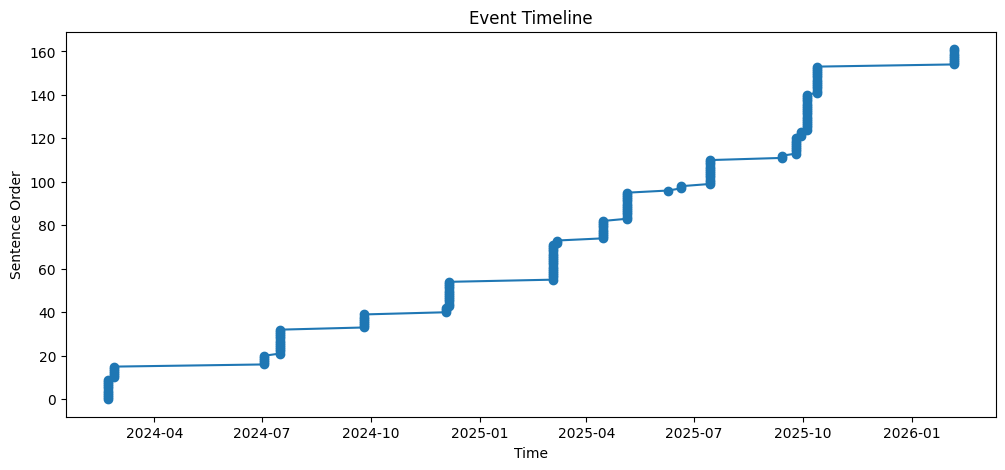

In [418]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

## Event Clustering

In [419]:
import hdbscan

In [420]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,
    metric='euclidean',
    # min_samples = 2
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [421]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,1150,1289431,"Besides today’s showcase, the Maxis 5G-Advance...",2024-02-22,5G,18,0
1,115,1289436,"5G-Advanced, also known as promises up to 10 t...",2024-02-22,5G,18,0
2,114,1289436,The '5G-Advanced Trial Showcase' included a li...,2024-02-22,5G,18,0
3,113,1289436,"Today, Maxis and Huawei have successfully stag...",2024-02-22,5G,18,0
4,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,18,0


In [422]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 2
 0    147
-1      9
 1      6
Name: event_id, dtype: int64


In [423]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

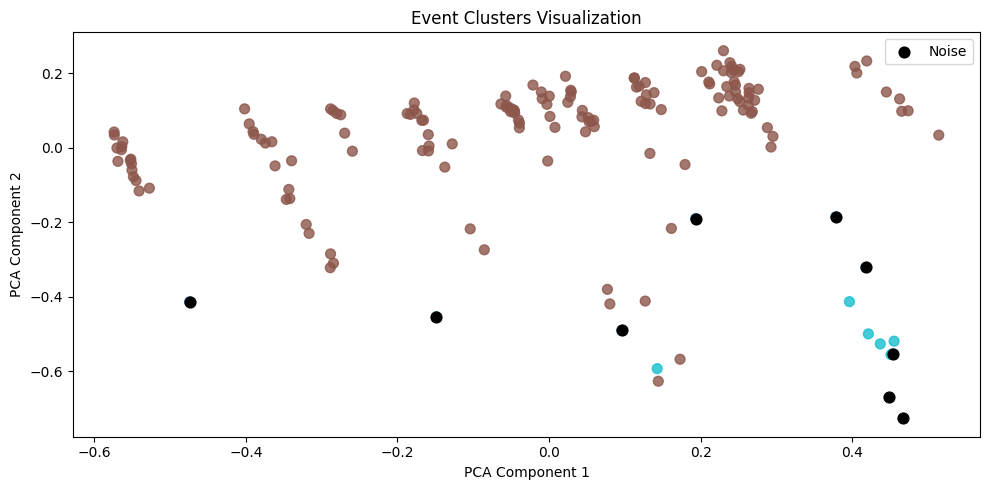

In [424]:
plt.style.use('default')
plt.figure(figsize=(10,5))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
    cmap="tab10",
    s=50,
    alpha=0.8,
)

noise_idx = np.where(event_labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(10, len(noise_idx)), replace=False)

plt.scatter(
    reduced_embeddings[noise_sample,0],
    reduced_embeddings[noise_sample,1],
    color="black",
    s=60,
    label="Noise"
)

plt.title("Event Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend()

plt.tight_layout()
plt.show()

In [425]:
print(sorted(episode_df["event_id"].unique()))
episode_df["event_id"].unique()

[-1, 0, 1]


array([ 0, -1,  1], dtype=int64)

## Event Labelling

In [426]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [427]:
def generate_event_tag(sentence):

    vectorizer = TfidfVectorizer(stop_words='english', max_features=8)
    
    X = vectorizer.fit_transform([sentence])
    
    keywords = vectorizer.get_feature_names_out()

    tag = " ".join(keywords)

    return tag

In [428]:
from sklearn.metrics.pairwise import cosine_similarity

In [429]:
import textwrap


episode_df["event_tag"] = ""

for event in episode_df["event_id"].unique():

    if event == -1:
        continue

    cluster = episode_df[episode_df["event_id"] == event]

    cluster_embeddings = episode_embeddings[cluster.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    central_index = similarities.argmax()

    rep_sentence = cluster.iloc[central_index]["sentence"]
    
    wrapped = textwrap.fill(rep_sentence,width=80)
    
    print(f"\n==========Event {event}==========")
    print(f'"{wrapped}"\n')
    print("Similarity:", similarities.max())
    print(f"===========================")

    tag = generate_event_tag(rep_sentence)

    episode_df.loc[episode_df["event_id"] == event, "event_tag"] = tag


==========Event 0==========
"U Mobile is targeting 80% coverage of populated areas (COPA) with its rollout of
the nation's second 5G network within the first 12 months of rollout."

Similarity: 0.9893137194429301

==========Event 1==========
"It may only be in the next two to three generations of mobile phones that we can
fully benefit from it,” he said"

Similarity: 0.9779914420835235


In [430]:
event_tag_map = (
    episode_df
    .drop_duplicates(subset=["event_id"])
    .sort_values("event_id")[["event_id", "event_tag"]]
)

print(event_tag_map)

    event_id                                     event_tag
9         -1                                              
0          0   12 5g 80 areas copa coverage mobile rollout
72         1  benefit fully generations mobile phones said


In [431]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    min_date = episode_df[episode_df["event_id"] == event]["published_date"].min().strftime("%d-%m-%Y")
    max_date = episode_df[episode_df["event_id"] == event]["published_date"].max().strftime("%d-%m-%Y")
    
    print("\n========================================================================================")
    print("Event ID:", event, "  {", list(event_tag_map.event_tag)[event+1],"}")
    print(f"Timeline: {min_date if min_date == max_date else f'{min_date} to {max_date}'}")
    print("========================================================================================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(5)
    episode_df[episode_df["event_id"] == event].to_csv(fr"dataset\fineTuned\events\balanced\eventID-{event}.csv",index=False)

    # for s in event_sentences:
    #     wrapped = textwrap.fill(s,width=100)
    #     print("-", wrapped)


Event ID: 0   { 12 5g 80 areas copa coverage mobile rollout }
Timeline: 22-02-2024 to 05-02-2026

Event ID: 1   { benefit fully generations mobile phones said }
Timeline: 07-03-2025 to 04-10-2025


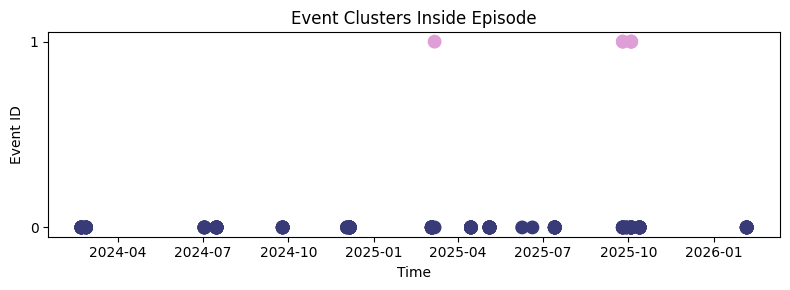

In [432]:
plt.figure(figsize=(8,3))

df_plot = episode_df[episode_df['event_id'] != -1]

plt.scatter(
    df_plot["published_date"],
    df_plot["event_id"],
    c=df_plot["event_id"],
    cmap="tab20b",
    s=80,
    alpha=1
)

plt.yticks(sorted(df_plot["event_id"].unique()))

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.tight_layout()
plt.show()